**这是我对 Gamelytics: 移动分析挑战赛 (https://www.kaggle.com/datasets/debs2x/gamelytics-mobile-analytics-challenge) 的实现。**
<br><br>
> ***任务 1（每日留存率）和任务 2（A/B 测试）已完成！！！** 任务 3（基于事件的性能评估）即将完成。*

**任务 1：留存率分析**

<br>🔍 目标：计算玩家从注册日期开始的每日留存率。
<br>📄 数据来源：

* reg_data.csv：包含用户注册时间戳（reg_ts）和唯一用户 ID（uid）。
* auth_data.csv：包含用户登录时间戳（auth_ts）和唯一用户 ID（uid）。

💡 挑战：开发一个 Python 函数来计算留存率，使其能够在完整数据集和较小样本上测试性能。

In [1]:
import matplotlib.pyplot as plt

# ===================== 全局中文&学术样式配置 =====================
plt.rcParams["font.family"] = ["SimHei"]  # 兼容Windows/Linux/Mac
plt.rcParams["axes.unicode_minus"] = False  # 负号正常显示
plt.rcParams["font.size"] = 12              # 基础字号
plt.rcParams["axes.titlesize"] = 14         # 标题字号
plt.rcParams["axes.labelsize"] = 12          # 坐标轴标签
plt.rcParams["xtick.labelsize"] = 10         # 刻度字号
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10         # 图例字号
plt.rcParams["figure.dpi"] = 300            # 屏幕渲染分辨率
plt.rcParams["figure.figsize"] = (6, 4)     # 论文标准图尺寸（单栏）
plt.rcParams["axes.spines.top"] = False     # 隐藏上边框
plt.rcParams["axes.spines.right"] = False   # 隐藏右边框
plt.rcParams["lines.linewidth"] = 1.5       # 线条粗细
plt.rcParams["lines.markersize"] = 4        # 标记大小
plt.rcParams["grid.alpha"] = 0.3            # 网格透明度
# =================================================================

In [2]:
# TL;DR - 这里是函数。
# 但如果你想了解我的思考过程并
# 看到另一种实现方式，请继续往下读。

import numpy as np
import pandas as pd

registration = pd.read_csv("reg_data.csv", sep=';')
login = pd.read_csv("auth_data.csv", sep=';')

"""
    接收两个 DataFrame，分别包含用户注册时间戳和用户登录时间戳，计算玩家的每日留存率。
    
    参数:
        reg_data (DataFrame): 用户注册时间戳（reg_ts）和唯一用户 ID（uid）
        auth_data (DataFrame): 用户登录时间戳和唯一用户 ID
        
    返回:
        retention_rate (DataFrame): 注册后天数以及留存用户百分比
"""
def daily_retention(reg_data, auth_data):
    merged_df = pd.merge(reg_data, auth_data, on='uid', how='left')
    merged_df['days_since_reg'] = (merged_df['auth_ts'] - 
                                   merged_df['reg_ts']) // (60*60*24)
    loginCount = (
        merged_df.groupby('days_since_reg')['auth_ts']
        .count()
        .reset_index(name='login_count')
        .sort_values(by='days_since_reg', ascending=True)
    )

    loginCount['login_percent'] = (loginCount['login_count'] / 
                                   merged_df['uid'].nunique()) * 100

    results = loginCount[loginCount['days_since_reg'] % 10 == 0].reset_index(drop=True).drop(columns=['login_count'])
    
    return results.head(38)


print(daily_retention(registration, login))

    days_since_reg  login_percent
0                0       100.0000
1               10         5.1070
2               20         3.7987
3               30         2.6259
4               40         1.5905
5               50         1.1790
6               60         1.1293
7               70         1.1338
8               80         1.1157
9               90         1.0839
10             100         1.0716
11             110         1.0460
12             120         1.0336
13             130         1.0181
14             140         0.9946
15             150         1.0001
16             160         0.9508
17             170         0.9397
18             180         0.9302
19             190         0.9250
20             200         0.8976
21             210         0.8837
22             220         0.8888
23             230         0.8455
24             240         0.8405
25             250         0.8286
26             260         0.8052
27             270         0.7989
28            

要完成这个任务，我们首先需要定义"每日留存率"。
<br>
有两种可能的定义：
1. 在注册后第 x 天回来的玩家百分比，无论注册日期如何。
2. 来自某个玩家群组的玩家回来的百分比。在我们的情况下，根据可用数据，基于注册日期创建群组是最合理的。

第一种方式更直接，而且考虑到数据有限，计算起来也更有意义，所以我们先实现这种方式。

我们的第一段代码将是 Kaggle 贴心提供的通用、自动生成的库导入，

In [3]:
# 此 Python 3 环境预装了许多有用的数据分析库
# 它由 kaggle/python Docker 镜像定义：https://github.com/kaggle/docker-python
# 以下是几个有用的示例包

import numpy as np # 线性代数
import pandas as pd # 数据处理，CSV 文件 I/O（例如 pd.read_csv）

# 输入数据文件位于只读的 "../input/" 目录中
# 例如，运行以下代码（点击运行或按 Shift+Enter）将列出输入目录下的所有文件

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 你可以向当前目录 (/kaggle/working/) 写入最多 20GB 的内容，当你使用"保存并全部运行"创建版本时，这些内容会被保留
# 你也可以向 /kaggle/temp/ 写入临时文件，但它们不会在当前会话之外被保存

我已经将挑战数据导入到这个环境中，但它们都是 CSV 文件——只是文本文件而已。为了将其转换为可以操作的行列结构的数据表，我们使用 pandas 库将其转换为一种称为 DataFrame 的数据结构。

In [4]:
# 将 reg_data.csv 和 auth_data.csv 转换为 DataFrame
# 这可能需要一些时间，因为一张表有一百万条记录，另一张有九百万条
# 注意，pandas 默认使用逗号分隔值。我们的数据使用分号，所以我们在参数中指定这一点。
registration = pd.read_csv("reg_data.csv", sep=';')
login = pd.read_csv("auth_data.csv", sep=';')

In [5]:
# 让我们快速查看数据，了解其包含的内容
# （虽然挑战描述中也说了，但这是一种好习惯）。
print(registration.head())
print(registration.info())

print("\n\n")

print(login.head())
print(login.info())

      reg_ts  uid
0  911382223    1
1  932683089    2
2  947802447    3
3  959523541    4
4  969103313    5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB
None



     auth_ts  uid
0  911382223    1
1  932683089    2
2  932921206    2
3  933393015    2
4  933875379    2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB
None


我们看到了时间戳和用户 ID。时间戳是 Unix 格式的，这意味着这些值表示自 1970 年 1 月 1 日以来的秒数。
<br><br>
让我们合并两张表，这样每一行就包含用户 ID、注册时间戳和登录时间戳。我们将使用左连接（left join），注册表在左侧，因为我们希望包含那些已注册但未登录的用户（即他们不在登录 DataFrame 中）。

In [6]:
merged_df = pd.merge(registration, login, on='uid', how='left')
print(merged_df.head())

      reg_ts  uid    auth_ts
0  911382223    1  911382223
1  932683089    2  932683089
2  932683089    2  932921206
3  932683089    2  933393015
4  932683089    2  933875379


看起来没问题。我们可以调整列的顺序，但现在这不重要。
<br><br>
现在我们将添加一个表示注册后天数的列。因此，如果有人在 2013 年 1 月 1 日注册，并在 2013 年 1 月 2 日登录，那么该列中该次登录的值为 1。对于在 1998 年 11 月 12 日注册并在 1998 年 11 月 13 日登录的人，该值也将是 1。
<br><br>
我们将通过登录时间戳减去注册时间戳，然后除以 60*60*24（一天中的秒数）来创建此列。我们使用整数除法，这样会截断小数部分，结果是完整的天数，比如第 13 天而不是第 13.96475 天。

In [7]:
merged_df['days_since_reg'] = (merged_df['auth_ts'] - merged_df['reg_ts']) // (60*60*24)
print(merged_df.head(20)) # head 函数打印前 5 条或指定的 n 条记录

       reg_ts  uid    auth_ts  days_since_reg
0   911382223    1  911382223               0
1   932683089    2  932683089               0
2   932683089    2  932921206               2
3   932683089    2  933393015               8
4   932683089    2  933875379              13
5   932683089    2  934372615              19
6   932683089    2  934662633              22
7   932683089    2  935002586              26
8   932683089    2  935141232              28
9   932683089    2  935682752              34
10  932683089    2  935997357              38
11  932683089    2  936224929              40
12  932683089    2  936369549              42
13  932683089    2  936845332              48
14  932683089    2  937325130              53
15  932683089    2  937837910              59
16  932683089    2  938323218              65
17  932683089    2  938759547              70
18  932683089    2  939083581              74
19  932683089    2  939361601              77


用户 2 似乎登录非常频繁。
<br>
虽然与留存率无关，但我们来看看用户 2 登录了多少次？

In [8]:
count = (merged_df['uid'] == 2).sum()
print(count)

1929


1929 次！我想知道谁的登录次数最多？

In [9]:
most_common_uid = merged_df['uid'].value_counts().idxmax()
frequency = merged_df['uid'].value_counts().max()

print(f"User {most_common_uid}, with {frequency} logins.")

User 2, with 1929 logins.


所以用户 2 是我们最活跃的玩家！这是一个有趣的数据留存分析之外的小插曲。
<br><br>
我们仍然需要计算留存率。让我们通过按天数分组来获取每天注册后登录的人数（这也是为什么我们之前除法时需要截断；多个第 13 天的条目会归为一组，但第 13.4 天、第 13.2 天和第 13.9834 天则不会）。请确保按注册日期排序！
<br><br>
这可以通过 SQL 的 GROUP BY 来实现，但我们使用的是 Python。

In [10]:
# 注意：loginCount 是一个新的 DataFrame！
loginCount = merged_df.groupby(['days_since_reg'])['auth_ts'].count().reset_index(name='login_count').sort_values(by='days_since_reg', ascending=True)
print(loginCount.head())

   days_since_reg  login_count
0               0      1000000
1               1        40202
2               2        42991
3               3        49152
4               4        56070


我们快完成了。现在只需要将登录计数转换为百分比，方法是除以注册总人数，不过我们也可以保留登录计数这一列。

In [11]:
loginCount['login_percent'] = (loginCount['login_count'] / merged_df['uid'].nunique()) * 100
print(loginCount.head(10))

   days_since_reg  login_count  login_percent
0               0      1000000       100.0000
1               1        40202         4.0202
2               2        42991         4.2991
3               3        49152         4.9152
4               4        56070         5.6070
5               5        63713         6.3713
6               6        72773         7.2773
7               7        43626         4.3626
8               8        49667         4.9667
9               9        50373         5.0373


很好！一切看起来都很准确，尽管结果可能不如预期——注册当天之后留存率很低；100% 的注册玩家在注册当天登录了，而随着天数的推移，这个比例会发生变化。
<br><br>
不过我们想如何呈现这些数据呢？我们可以直接返回整个 DataFrame——让我们看看它有多少条目。

In [12]:
print(loginCount.info())
print(loginCount)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5916 entries, 0 to 5915
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   days_since_reg  5916 non-null   int64  
 1   login_count     5916 non-null   int64  
 2   login_percent   5916 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 138.8 KB
None
      days_since_reg  login_count  login_percent
0                  0      1000000       100.0000
1                  1        40202         4.0202
2                  2        42991         4.2991
3                  3        49152         4.9152
4                  4        56070         5.6070
...              ...          ...            ...
5911            7715            1         0.0001
5912            7719            1         0.0001
5913            7720            1         0.0001
5914            7726            1         0.0001
5915            7728            1         0.0001

[5916 rows x 3 columns]

注意，days_since_reg 最高达到 7728 天，但只有 5916 个条目，这意味着在很多天里根本没有人登录！
<br><br>
无论如何，5916 个条目还是太多了。假设我们只是为报告之类的东西提取一个快速摘要，我们可以提取前几个条目，也许到每日留存率降到 1% 以下为止，或者按月提取。
<br><br>
如果我们每 30 天展示一次留存率，它在技术上仍然是每日留存率。我们只是以较低的频率对每日留存率进行抽样。

In [13]:
results = loginCount[loginCount['days_since_reg'] % 30 == 0].reset_index(drop=True).drop(columns=['login_count'])
print(results)

     days_since_reg  login_percent
0                 0       100.0000
1                30         2.6259
2                60         1.1293
3                90         1.0839
4               120         1.0336
..              ...            ...
186            6840         0.0001
187            6930         0.0001
188            7170         0.0001
189            7260         0.0001
190            7500         0.0001

[191 rows x 2 columns]


191 行好多了！不过让我们看看百分比首次降到 1% 以下是在什么时候，以确定显示所有这些行是否会是更好的选择。

In [14]:
first_below_1 = results.loc[results['login_percent'] < 1, 'days_since_reg'].min()
print(first_below_1)

180


返回所有行直到低于 1%，仍然会给我们 140 行（因为我们包含第 0 天而排除第 140 天）。比 5106 行好，但还不够理想。
<br>
**另外需要注意的是：** 仅仅因为某个条目低于 1%，并不意味着之后所有的留存率都会如此。它可能在 2135 天突然增加到 80%，尽管这不太可能。
<br><br>
既然有 7500 天，也许我们可以每 375 天返回 20 个条目？或者我们甚至可以每年 365 天返回一个条目。

In [15]:
results = loginCount[loginCount['days_since_reg'] % 365 == 0].reset_index(drop=True).drop(columns=['login_count'])
print(results)

    days_since_reg  login_percent
0                0       100.0000
1              365         0.6935
2              730         0.3746
3             1095         0.2096
4             1460         0.1111
5             1825         0.0589
6             2190         0.0344
7             2555         0.0185
8             2920         0.0103
9             3285         0.0049
10            3650         0.0029
11            4015         0.0015
12            4380         0.0010
13            4745         0.0001
14            5110         0.0001
15            5475         0.0001
16            5840         0.0001


这看起来不太乐观。注册日之后的每次留存率都低于 1%。不过我们确实得到了玩家留存率的全面视图！
<br><br>
让我们只返回第一年的数据，每 10 天为一组，我们可以根据需要调整参数来查看更多或更少的留存率数据。

In [16]:
results = loginCount[loginCount['days_since_reg'] % 10 == 0].reset_index(drop=True).drop(columns=['login_count'])
print(results.head(38))

newResults = results.head(38)

    days_since_reg  login_percent
0                0       100.0000
1               10         5.1070
2               20         3.7987
3               30         2.6259
4               40         1.5905
5               50         1.1790
6               60         1.1293
7               70         1.1338
8               80         1.1157
9               90         1.0839
10             100         1.0716
11             110         1.0460
12             120         1.0336
13             130         1.0181
14             140         0.9946
15             150         1.0001
16             160         0.9508
17             170         0.9397
18             180         0.9302
19             190         0.9250
20             200         0.8976
21             210         0.8837
22             220         0.8888
23             230         0.8455
24             240         0.8405
25             250         0.8286
26             260         0.8052
27             270         0.7989
28            

太好了！我们的最后一步是将其打包成一个函数。

In [17]:
def daily_retention(reg_data, auth_data):
    merged_df = pd.merge(reg_data, auth_data, on='uid', how='left')
    merged_df['days_since_reg'] = (merged_df['auth_ts'] - 
                                   merged_df['reg_ts']) // (60*60*24)
    loginCount = (
        merged_df.groupby('days_since_reg')['auth_ts']
        .count()
        .reset_index(name='login_count')
        .sort_values(by='days_since_reg', ascending=True)
    )

    loginCount['login_percent'] = (loginCount['login_count'] / 
                                   merged_df['uid'].nunique()) * 100

    results = loginCount[loginCount['days_since_reg'] % 10 == 0].reset_index(drop=True).drop(columns=['login_count'])
    
    return results.head(38)


我们基本上完成了！
<br><br>
……不过你知道还有什么会很有趣吗？
<br><br>
画图！让我们快速绘制一张结果的折线图。

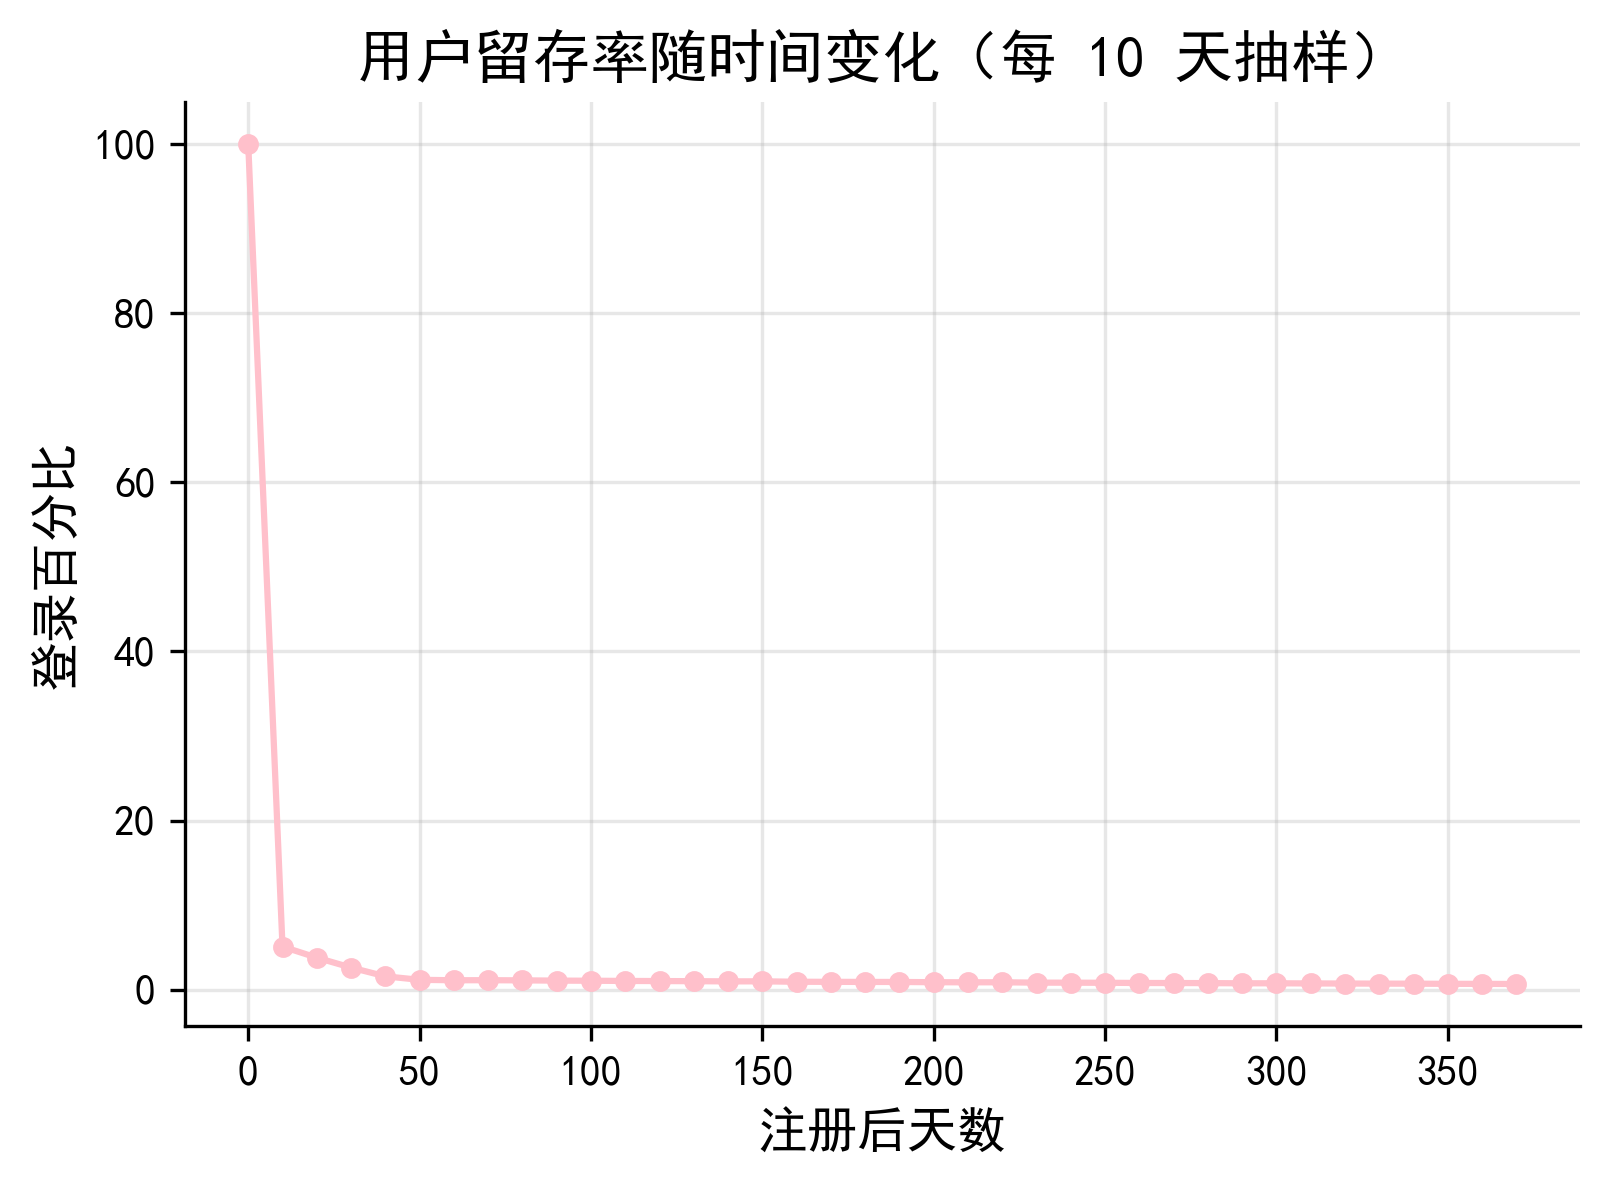

In [18]:
import matplotlib.pyplot as plt

final_results = daily_retention(registration, login)

plt.plot(newResults['days_since_reg'], final_results['login_percent'], marker='o', color='pink')
plt.title('用户留存率随时间变化（每 10 天抽样）')
plt.xlabel('注册后天数')
plt.ylabel('登录百分比')
plt.grid(True)
plt.show()


多么有趣的变化趋势。
<br><br>
无论这个手机游戏的结果如何，我们现在已经编写了一个计算玩家每日留存率的函数，参数易于修改，还附带了一张折线图！

现在我们可以转向第二种实现方式——按群组计算每日留存率，具体来说就是按注册时间对用户进行分组。这种方式的实际应用场景是：如果我们在某一天推出了新功能或更新，我们可以查看在该日期或之后注册的用户的留存率。如果这些玩家的留存率更高，则意味着该功能可能是提高玩家留存率的一个因素。
<br><br>
让我们重新加载干净的数据，即只包含 reg_ts、uid 和 auth_ts 的合并 DataFrame。

In [19]:
registration = pd.read_csv("reg_data.csv", sep=';')
login = pd.read_csv("auth_data.csv", sep=';')
merged_df = pd.merge(registration, login, on='uid', how='left')
print(merged_df.head())

      reg_ts  uid    auth_ts
0  911382223    1  911382223
1  932683089    2  932683089
2  932683089    2  932921206
3  932683089    2  933393015
4  932683089    2  933875379


很好！由于此每日留存率将依赖于实际的注册日期，我们将创建 2 个新列，将 reg_ts 和 auth_ts 转换为日期，然后删除 reg_ts 和 auth_ts。我们还将添加一列表示每次登录距离注册的天数。
<br><br>
请注意，我们在注释行中需要小心处理不同的数据类型以获得想要的结果。

In [20]:
# 一些快速说明：
# merged_df['reg_date'] 表示 reg_date 是 DataFrame merged_df 中的一个 Series，其中 Series 是一个带标签的列
# .dt 是一个 Pandas 访问器，允许对日期时间值使用特殊方法。
# 使用 .dt.normalize() 而不是 .dt.date()，因为 .normalize() 保留 dtype 为 datetime64[ns] 但将时间设置为 00:00:00，
# 而 .date() 会将每个值转换为 Python 的 date 对象。

merged_df['reg_date'] = pd.to_datetime(merged_df['reg_ts'], unit='s').dt.normalize()
merged_df['auth_date'] = pd.to_datetime(merged_df['auth_ts'], unit='s').dt.normalize()
dated_data = merged_df.drop(['reg_ts', 'auth_ts'], axis=1)

# 这个减法之所以有效，是因为两列具有日期时间属性；结果是一个 timedelta64[ns] 类型的值。
# 我们可以将其转换为表示天数的整数，而不是让其保持为
# 表示持续时间的 timedelta 序列（基本上允许对象知道其单位是天），
# 因为这是多余的信息，在可视化和标签中会碍事——在绘图时也可能导致问题。
# 然而，我们希望在后续筛选时保持日期时间格式。
# 对于原始数据，我们可以保持为 timedelta64[ns] 对象，我们的计算仍然可以正常工作。
dated_data['days_since_reg'] = (dated_data['auth_date'] - dated_data['reg_date'])

print(dated_data.head())

# 查看数据类型以加深你的理解！
print("\n\n", dated_data.dtypes)

   uid   reg_date  auth_date days_since_reg
0    1 1998-11-18 1998-11-18         0 days
1    2 1999-07-22 1999-07-22         0 days
2    2 1999-07-22 1999-07-25         3 days
3    2 1999-07-22 1999-07-31         9 days
4    2 1999-07-22 1999-08-05        14 days


 uid                         int64
reg_date           datetime64[ns]
auth_date          datetime64[ns]
days_since_reg    timedelta64[ns]
dtype: object


很好！让我们按注册日期和注册后天数分组，统计唯一用户数。这将告诉我们，例如，所有在 2020 年 9 月 14 日注册并在注册后 5 天登录的用户，所有在 2020 年 9 月 14 日注册并在注册后 6 天登录的用户，以此类推。请查看下面打印的结果，注意我们打印的是 tail——数据的末尾——而不是 head，因为开头全部是 1，这表明游戏在初期没有很多玩家。

In [21]:
retention = dated_data.groupby(['reg_date', 'days_since_reg'])['uid'].nunique().reset_index(name='active_users')
print(retention.tail(50))

          reg_date days_since_reg  active_users
2716178 2020-09-14         5 days           105
2716179 2020-09-14         6 days           113
2716180 2020-09-14         7 days           102
2716181 2020-09-14         8 days            72
2716182 2020-09-14         9 days            47
2716183 2020-09-15         0 days          1623
2716184 2020-09-15         1 days            36
2716185 2020-09-15         2 days            66
2716186 2020-09-15         3 days            74
2716187 2020-09-15         4 days            98
2716188 2020-09-15         5 days            91
2716189 2020-09-15         6 days           112
2716190 2020-09-15         7 days            92
2716191 2020-09-15         8 days            40
2716192 2020-09-16         0 days          1625
2716193 2020-09-16         1 days            31
2716194 2020-09-16         2 days            69
2716195 2020-09-16         3 days            75
2716196 2020-09-16         4 days            76
2716197 2020-09-16         5 days       

现在我们将通过按注册日期分组来创建群组。

In [22]:
# 注意：不使用 reset_index()，cohort 将是一个 Series。使用它后，cohorts 是一个 DataFrame。
cohorts = merged_df.groupby(['reg_date'])['uid'].nunique().reset_index(name='total_in_cohort')
print(cohorts)

       reg_date  total_in_cohort
0    1998-11-18                1
1    1999-07-22                1
2    2000-01-13                1
3    2000-05-28                1
4    2000-09-16                1
...         ...              ...
5105 2020-09-19             1634
5106 2020-09-20             1636
5107 2020-09-21             1638
5108 2020-09-22             1641
5109 2020-09-23             1048

[5110 rows x 2 columns]


有 5110 个唯一的注册日期！这很合理，因为注册数据文件中有 100 万条记录，而数据跨度从 1998 年到 2020 年（22 年！）。
<br><br>
我们肯定需要像之前那样有选择性地筛选数据，但现在我们先通过将原始留存数据集（还没有百分比）与群组数据合并来计算每个群组的留存率。

In [23]:
retention = retention.merge(cohorts, on='reg_date', how='left')
print(retention.tail())

          reg_date days_since_reg  active_users  total_in_cohort
2716223 2020-09-21         1 days            31             1638
2716224 2020-09-21         2 days            49             1638
2716225 2020-09-22         0 days          1641             1641
2716226 2020-09-22         1 days            14             1641
2716227 2020-09-23         0 days          1048             1048


我们快完成了！现在只需要创建一个新列，将 active_users 除以 total_in_cohort。

In [24]:
retention['retention_rate'] = ((retention['active_users'] / retention['total_in_cohort']) * 100).round(2)
print(retention.tail(10))

          reg_date days_since_reg  active_users  total_in_cohort  \
2716218 2020-09-20         0 days          1636             1636   
2716219 2020-09-20         1 days            40             1636   
2716220 2020-09-20         2 days            71             1636   
2716221 2020-09-20         3 days            39             1636   
2716222 2020-09-21         0 days          1638             1638   
2716223 2020-09-21         1 days            31             1638   
2716224 2020-09-21         2 days            49             1638   
2716225 2020-09-22         0 days          1641             1641   
2716226 2020-09-22         1 days            14             1641   
2716227 2020-09-23         0 days          1048             1048   

         retention_rate  
2716218          100.00  
2716219            2.44  
2716220            4.34  
2716221            2.38  
2716222          100.00  
2716223            1.89  
2716224            2.99  
2716225          100.00  
2716226          

我们也可以像之前那样制作折线图——但是我们有 5110 个注册日期，也就是 5110 个群组，折线图上会有 5110 条线，每条线代表一个群组的留存率。所以我们先减少返回的数据。
<br><br>
注册后 0 天的留存率其实不太重要，所以让我们先删除 days_since_reg 为 0 的行。然后，由于数据跨度大约为 22 年，如下所示：

In [25]:
print(retention['reg_date'].min())
print(retention['reg_date'].max())

1998-11-18 00:00:00
2020-09-23 00:00:00


让我们允许按注册年份和注册后天数进行筛选。
<br><br>
回到我们假设的某个功能在特定日期推出的场景，这使我们能够查看在该功能实施日期附近注册的玩家的行为，并查看大约一个月内的留存率，而不是 7000 天之后。
<br><br>
对于这个场景，假设某个功能于 2020 年 1 月 1 日推出，我们关注注册后最多一个月的留存率。

In [26]:
# 保留 days_since_reg 不为 0 的行
results = retention[retention['days_since_reg'].dt.days != 0].copy()

# 按注册日期范围筛选（群组选择）
start_date = '2020-01-01'
end_date = '2020-01-15'
results = results[(results['reg_date'] >= start_date) & (results['reg_date'] <= end_date)].copy()

# 按 days_since_reg 范围筛选
min_days = 1
max_days = 31
results = results[(results['days_since_reg'].dt.days >= min_days) & 
                  (results['days_since_reg'].dt.days <= max_days)].copy()

# 重置索引，因为我们提取了带有原始索引的行（跳过了 days_since_reg 为 0 的行），索引不再准确
results.reset_index(drop=True, inplace=True)

# 取消显示行数限制
pd.set_option('display.max_rows', None)
print(results)

# 确保重置，以免下次打印一百万行时电脑崩溃
pd.reset_option('display.max_rows')

      reg_date days_since_reg  active_users  total_in_cohort  retention_rate
0   2020-01-01         1 days            28             1061            2.64
1   2020-01-01         2 days            48             1061            4.52
2   2020-01-01         3 days            36             1061            3.39
3   2020-01-01         4 days            60             1061            5.66
4   2020-01-01         5 days            62             1061            5.84
5   2020-01-01         6 days            80             1061            7.54
6   2020-01-01         7 days            53             1061            5.00
7   2020-01-01         8 days            47             1061            4.43
8   2020-01-01         9 days            47             1061            4.43
9   2020-01-01        10 days            57             1061            5.37
10  2020-01-01        11 days            69             1061            6.50
11  2020-01-01        12 days            49             1061            4.62

我们完成了！我们也可以删除 active_users 和 total_in_cohort 列——不过我想保留它们，所以就不删了。让我们也快速绘制一张折线图：

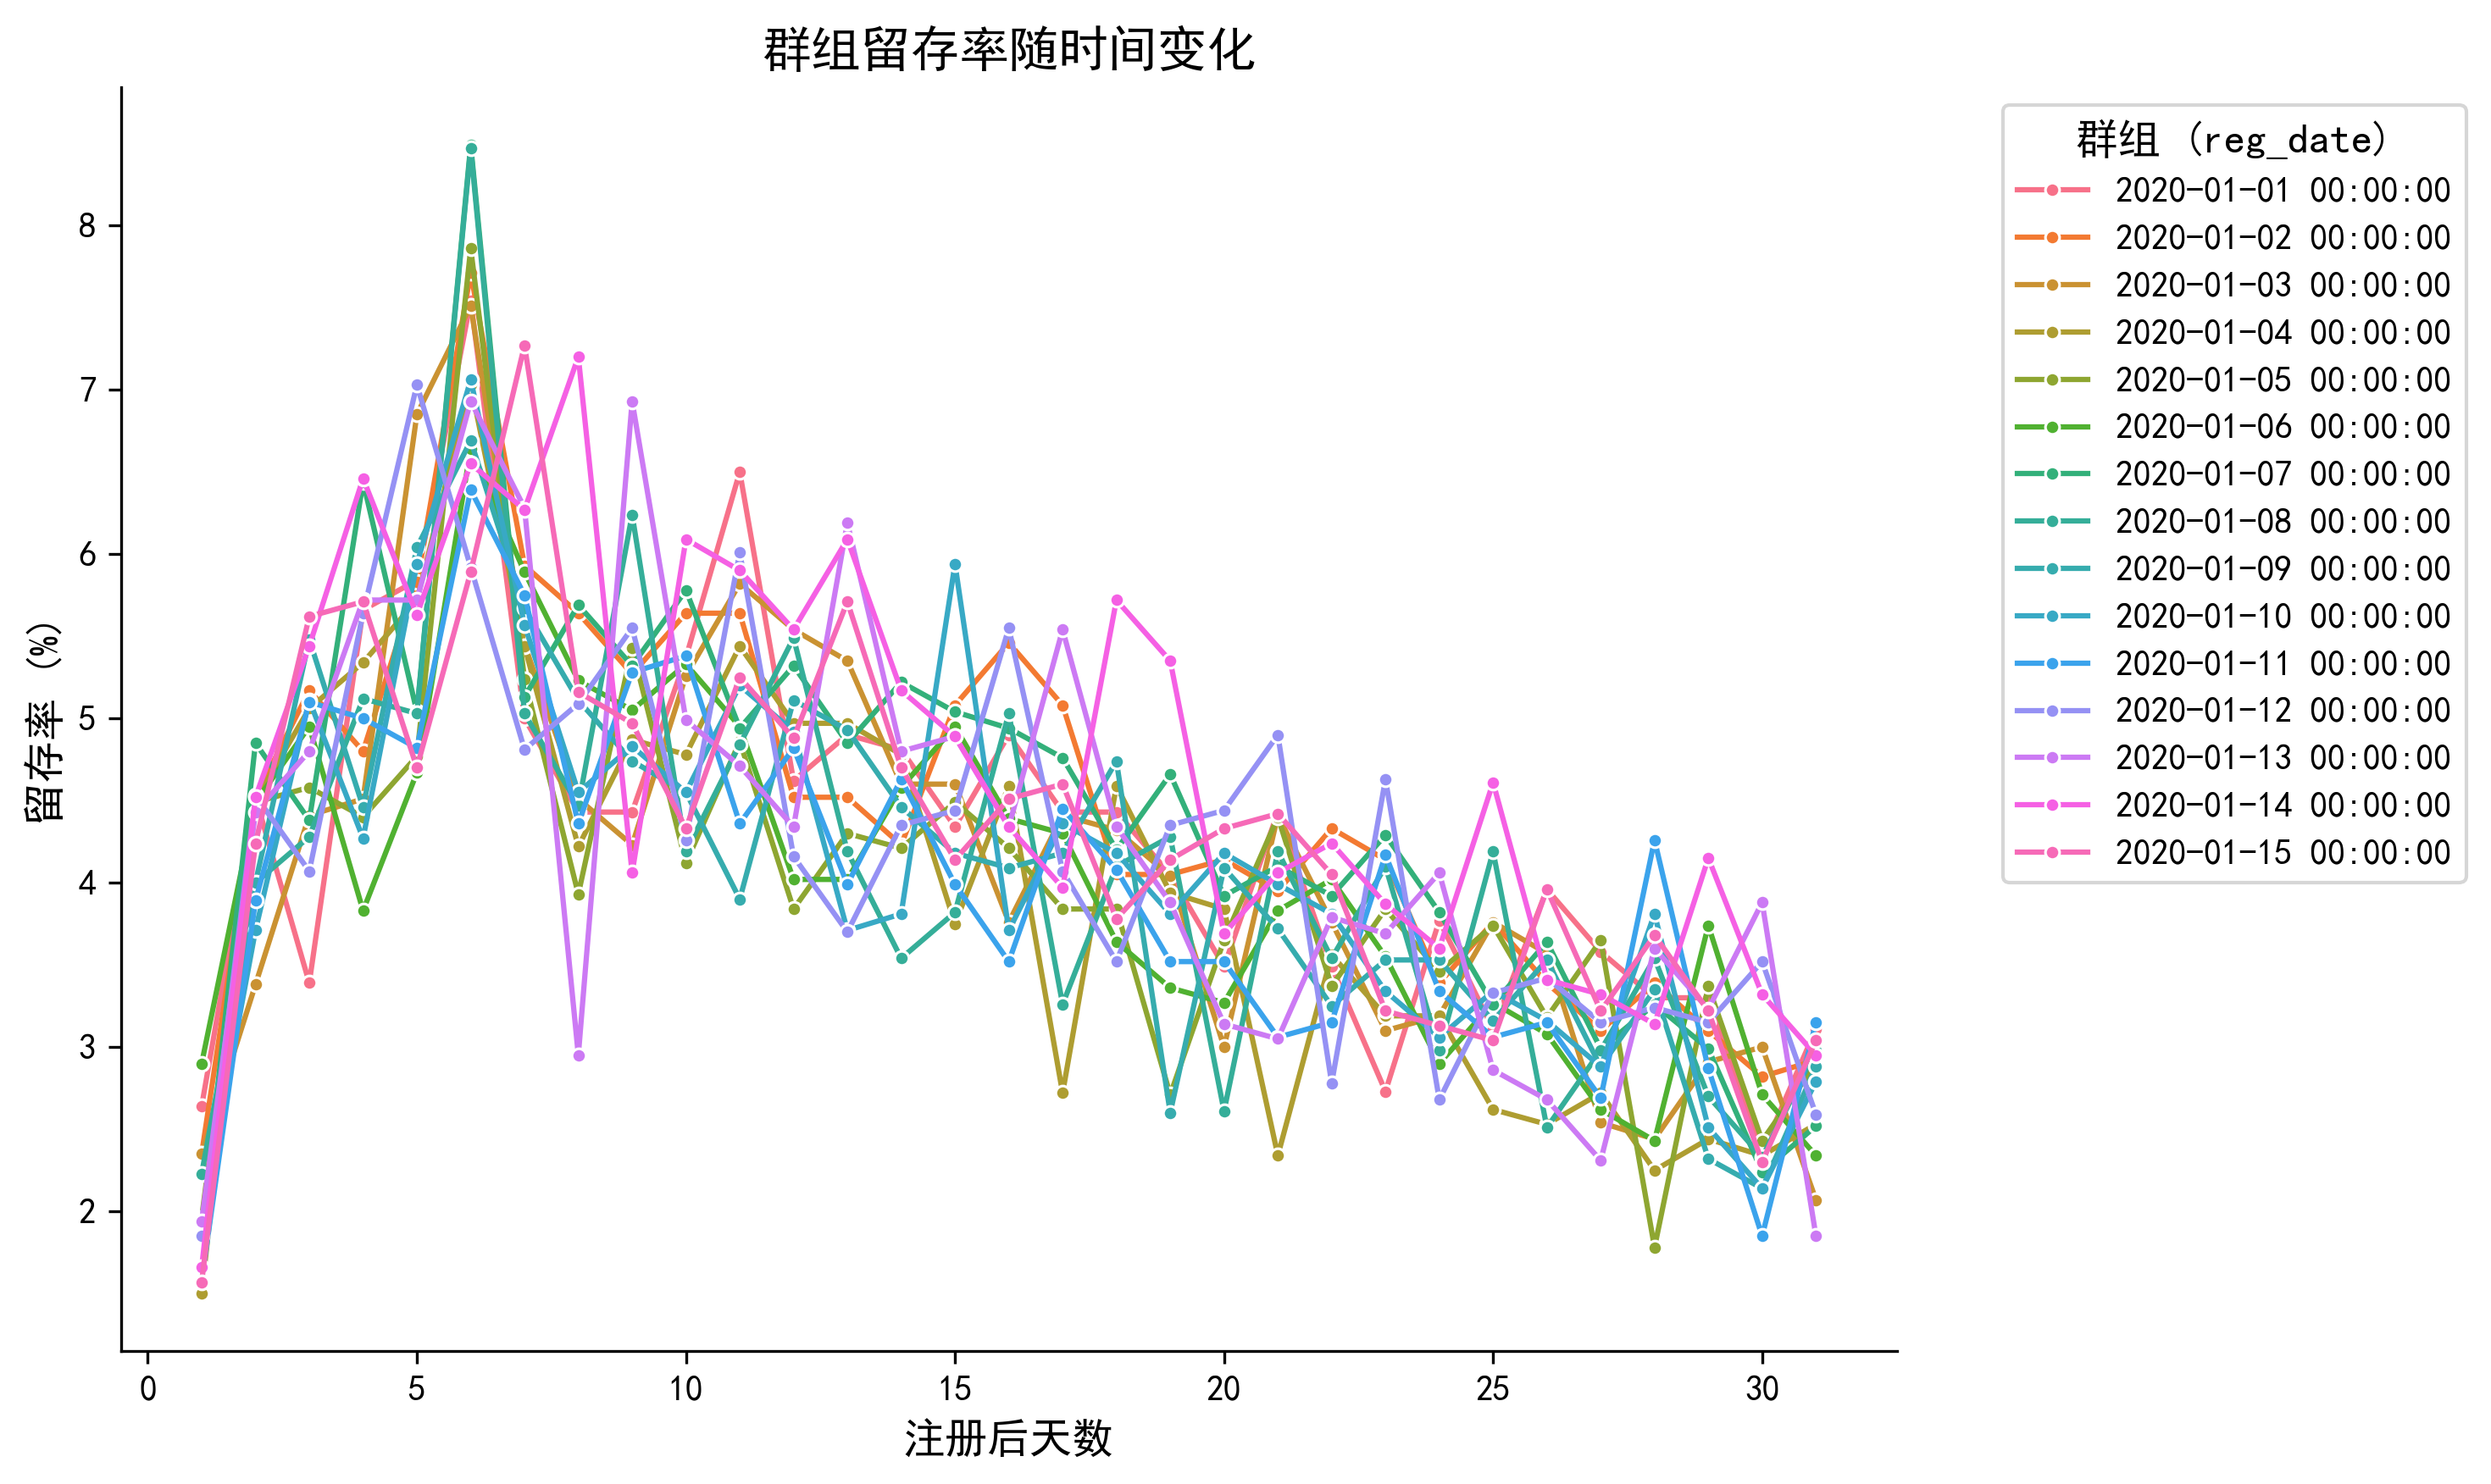

In [27]:
# 隐藏警告——它们只是告诉我们 pd.unique 在未来的 pandas 版本中将不可用
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# 不过在此之前，我们需要将 days_since_reg 的 dtype 改为日期格式，以便坐标轴正确显示数字。
results['days_since_reg'] = results['days_since_reg'].dt.days

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制留存率曲线
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=results,
    x='days_since_reg',
    y='retention_rate',
    hue='reg_date',
    marker='o'
)

# 样式设置
plt.title('群组留存率随时间变化', fontsize=14)
plt.xlabel('注册后天数')
plt.ylabel('留存率 (%)')
plt.legend(title='群组 (reg_date)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


我们已经完成了第二种实现方式，任务 1 就此结束！🎉

让我们继续任务 2！

**任务 2：促销优惠的 A/B 测试**  

🔍 目标：通过比较关键收入指标，找出表现最佳的促销优惠组合。  

💰 背景：  

* 测试组的 ARPU 比对照组高 5%。  
* 在对照组中，202,103 名用户中有 1,928 名是付费用户。  
* 在测试组中，202,667 名用户中有 1,805 名是付费用户。  

📊 数据来源：  
* ab_test.csv：包含 user_id、revenue 和 testgroup 列。    

💡 挑战：决定哪个优惠组合表现最佳，并确定用于稳健评估的适当指标。


我们先来看一下数据。

In [28]:
import pandas as pd 

ab_data = pd.read_csv("ab_test.csv", sep=';') # 别忘了分隔符参数！
print(ab_data.head())

   user_id  revenue testgroup
0        1        0         b
1        2        0         a
2        3        0         a
3        4        0         b
4        5        0         b


很好，现在让我们来弄清楚几件事：
* 每行是否有唯一的 user_id？（没有重复）
* A 组还是 B 组是对照组？
* 我们如何判断哪个组表现更好？

虽然按照惯例我认为 A 组是对照组，但我们可以通过计算每组中付费用户的数量来正式确定哪个是哪个组（根据任务中的详细说明）
> 在对照组中，202,103 名用户中有 1,928 名是付费用户。在测试组中，202,667 名用户中有 1,805 名是付费用户。  

至于第二点，即我们如何实际完成任务——我认为测试组表现更好，因为它的付费用户较少但 ARPU（每用户平均收入）更高。不过我们可以使用标准公式/指标来确认。

In [29]:
# 让我们快速检查重复项（这个数据非常干净，所以我认为不会有重复，但检查一下总是好的）
# 然后看看 A 组有多少付费用户。

print(ab_data['user_id'].is_unique)

True


In [30]:
# .assign() 创建并返回我们 DataFrame 的一个副本，新增一列 True/False 表示用户是否付费（如果 revenue > 0）
# 我们按 testgroup 列分组，将所有 testgroup 为 a 的行"合并"到一起，所有 testgroup 为 b 的行合并到一起
# 然后我们对每个组中 is_payer = True 的行求和
ab_data.assign(is_payer = ab_data['revenue'] > 0).groupby('testgroup')['is_payer'].sum()

testgroup
a    1928
b    1805
Name: is_payer, dtype: int64

A 组 = 对照组，已确认。

现在我们只需要选择一些好的指标来明确判断 A 组还是 B 组表现更好。"更好"可以定义为：
* 哪个组的付费用户更多（转化成功率）
* 哪个组的每用户平均收入（ARPU）更高
* 哪个组的每付费用户平均收入（ARPPU）更高
* 哪个组的消费更稳定——每个人都消费 vs. 少数人消费很多（平均绝对偏差）

这些都非常直接，所以让我们按测试组对数据分组，然后显示 4 个额外的指标列。请注意，总收入虽然是一个很酷的指标，但由于 A 组和 B 组的规模不同，我们使用 ARPU 和 ARPPU 来代替。

In [31]:
# 注意，我四舍五入到 2 位小数。

ab_data.groupby('testgroup').agg(
    percent_paying=('revenue', lambda x: round((x > 0).mean() * 100, 2)),
    arpu=('revenue', lambda x: round(x.mean(), 2)),
    arppu=('revenue', lambda x: round(x[x > 0].mean(), 2)),
    mad=('revenue', lambda x: round((x - x.mean()).abs().mean(), 2))
)

,percent_paying,arpu,arppu,mad
testgroup,,,,
a,0.95,25.41,2664.00,50.34
b,0.89,26.75,3003.66,53.03


这很有趣！看起来 A 组有：
* 平均消费人数更多
* 消费更稳定

但 B 组有：
* 更多收入

所以这取决于所做的更改是什么。如果这个手机游戏正在测试某种**替代了另一个功能**的新功能，目的是让人们花更多钱——比如一个昂贵的战斗套装——那么我们可以说这个功能有效并且带来了更多收入。假设商店每季销售 5 件物品，其中一件更贵，那么消费人数略少、消费一致性有所变化是合理的。这完全没有问题，我会支持推出这个新功能，因为它能产生更多收入，而且不应该损害客户群的信任，因为大家都知道新物品会不断更换。

然而，如果我们所做的更改是 UI 方面的或其他什么的——这可能意味着实际上人们更难找到购物的途径，只有那些本来就会花很多钱的忠实用户才能找到购物按钮。在这种情况下，保持现有的 UI——保持 A 组的设计——将是我的建议。

任务 2 到此结束！🎉

在任务 3 完成后我们可以回过头来思考的一些未来问题：
* 我们能否编写一个函数，基于我们的 4 个指标为每个组的表现打分？
* 我们能否将玩家留存率与他们的消费行为进行比较？毕竟我们有 uid。

In [32]:
# 基于 4 个指标为 A/B 测试组打分 —— 普惠转化优先，提升付费渗透率，降低氪金门槛
# 
# 指标:
#   1. percent_paying — 付费转化率（↑ 越高越好）
#   2. arpu           — 每用户平均收入（↑ 越高越好）
#   3. arppu          — 每付费用户平均收入（↑ 越高越好）
#   4. mad            — 收入离散度 / 均值绝对偏差（↓ 越低越好，消费越均衡）
#
# 改进：用 Cohen's d 效应量替代 min-max 归一化，微小差异不再退化为 0 vs 100。

import pandas as pd
import numpy as np
from scipy import stats

In [33]:
def _cohens_d_score(vals_a, vals_b, higher_is_better=True):
    """
    Cohen's d 效应量 → 分数映射。
    分差 = min(50, |d| × 25)，基准 50。
    |d|=0.2(小)→55vs45  |d|=0.5(中)→62.5vs37.5  |d|=0.8(大)→70vs30  |d|≥2.0→100vs0
    """
    mean_a, mean_b = np.mean(vals_a), np.mean(vals_b)
    var_a, var_b = np.var(vals_a, ddof=1), np.var(vals_b, ddof=1)
    n_a, n_b = len(vals_a), len(vals_b)
    
    pooled_std = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    
    if pooled_std < 1e-15:
        d = 0.0
    else:
        d = (mean_a - mean_b) / pooled_std
    
    score_diff = min(50.0, abs(d) * 25.0)
    a_better = (d > 0) if higher_is_better else (d < 0)
    
    if a_better:
        score_a, score_b = 50.0 + score_diff, 50.0 - score_diff
    elif abs(d) < 1e-15:
        score_a = score_b = 50.0
    else:
        score_a, score_b = 50.0 - score_diff, 50.0 + score_diff
    
    return float(score_a), float(score_b), float(d)


def score_ab_groups(ab_df, weights=None, verbose=True):
    """
    基于 4 个指标为 A/B 测试组打分（Cohen's d 效应量驱动）。
    
    参数:
        ab_df (DataFrame): 含 user_id, revenue, testgroup 列的数据
        weights (dict):     各指标权重，默认 {'percent_paying':0.38, 'arpu':0.32,
                           'arppu':0.20, 'mad':0.10}
        verbose (bool):     是否打印详细报告
        
    返回:
        scores (DataFrame): 包含各指标得分、综合得分及排名
    """
    if weights is None:
        weights = {
            'percent_paying': 0.4,
            'arpu': 0.3,
            'arppu': 0.2,
            'mad': 0.1
        }
    
    groups = sorted(ab_df['testgroup'].unique())
    if len(groups) != 2:
        raise ValueError(f"仅支持两组 A/B 测试，当前有 {len(groups)} 组: {groups}")
    g_a, g_b = groups[0], groups[1]
    
    rev_a = ab_df[ab_df['testgroup'] == g_a]['revenue'].values
    rev_b = ab_df[ab_df['testgroup'] == g_b]['revenue'].values
    n_a, n_b = len(rev_a), len(rev_b)
    
    payers_a = rev_a[rev_a > 0]
    payers_b = rev_b[rev_b > 0]
    n_payers_a, n_payers_b = len(payers_a), len(payers_b)
    
    # ============================================================
    # 1. 原始指标计算
    # ============================================================
    pct_a = (rev_a > 0).mean() * 100
    pct_b = (rev_b > 0).mean() * 100
    
    arpu_a, arpu_b = rev_a.mean(), rev_b.mean()
    
    arppu_a = payers_a.mean() if n_payers_a > 0 else 0.0
    arppu_b = payers_b.mean() if n_payers_b > 0 else 0.0
    
    dev_a = np.abs(rev_a - arpu_a)
    dev_b = np.abs(rev_b - arpu_b)
    mad_a, mad_b = dev_a.mean(), dev_b.mean()
    
    # ============================================================
    # 2. Cohen's d 效应量评分
    # ============================================================
    
    s_pct_a, s_pct_b, d_pct = _cohens_d_score(
        (rev_a > 0).astype(float), (rev_b > 0).astype(float), higher_is_better=True
    )
    
    s_arpu_a, s_arpu_b, d_arpu = _cohens_d_score(
        rev_a, rev_b, higher_is_better=True
    )
    
    if n_payers_a >= 2 and n_payers_b >= 2:
        s_arppu_a, s_arppu_b, d_arppu = _cohens_d_score(
            payers_a, payers_b, higher_is_better=True
        )
    else:
        s_arppu_a, s_arppu_b, d_arppu = 50.0, 50.0, np.nan
    
    s_mad_a, s_mad_b, d_mad = _cohens_d_score(
        dev_a, dev_b, higher_is_better=False
    )
    
    # ============================================================
    # 3. 统计显著性检验
    # ============================================================
    
    contingency = np.array([
        [(rev_a > 0).sum(), (rev_a == 0).sum()],
        [(rev_b > 0).sum(), (rev_b == 0).sum()]
    ])
    chi2, p_chi2, _, _ = stats.chi2_contingency(contingency)
    
    t_arpu, p_arpu = stats.ttest_ind(rev_a, rev_b, equal_var=False)
    
    if n_payers_a >= 2 and n_payers_b >= 2:
        t_arppu, p_arppu = stats.ttest_ind(payers_a, payers_b, equal_var=False)
    else:
        t_arppu, p_arppu = np.nan, np.nan
    
    _, p_mad = stats.levene(rev_a, rev_b)
    
    # ============================================================
    # 4. 综合得分
    # ============================================================
    composite_a = (s_pct_a   * weights['percent_paying'] +
                   s_arpu_a  * weights['arpu'] +
                   s_arppu_a * weights['arppu'] +
                   s_mad_a   * weights['mad'])
    composite_b = (s_pct_b   * weights['percent_paying'] +
                   s_arpu_b  * weights['arpu'] +
                   s_arppu_b * weights['arppu'] +
                   s_mad_b   * weights['mad'])
    
    scores = pd.DataFrame({
        'testgroup':               [g_a, g_b],
        'percent_paying_raw_pct':  [pct_a, pct_b],
        'arpu_raw':                [arpu_a, arpu_b],
        'arppu_raw':               [arppu_a, arppu_b],
        'mad_raw':                 [mad_a, mad_b],
        'percent_paying_score':    [round(s_pct_a, 2),   round(s_pct_b, 2)],
        'arpu_score':              [round(s_arpu_a, 2),  round(s_arpu_b, 2)],
        'arppu_score':             [round(s_arppu_a, 2), round(s_arppu_b, 2)],
        'mad_score':               [round(s_mad_a, 2),   round(s_mad_b, 2)],
        'composite_score':         [round(composite_a, 2), round(composite_b, 2)],
    })
    scores['rank'] = scores['composite_score'].rank(ascending=False).astype(int)
    scores = scores.sort_values('rank')
    
    # ============================================================
    # 5. 报告
    # ============================================================
    if verbose:
        print("=" * 78)
        print("📊 A/B 测试组综合评分报告（Cohen's d 效应量驱动）")
        print("=" * 78)
        print(f"数据规模: 组 '{g_a}' {n_a:,} 用户 (付费 {n_payers_a:,}) | "
              f"组 '{g_b}' {n_b:,} 用户 (付费 {n_payers_b:,})")
        
        print(f"\n{'─' * 78}")
        print("🔢 原始指标 & 效应量 (Cohen's d)")
        print(f"{'─' * 78}")
        print(f"  {'指标':<18s} {'组 '+g_a:>10s} {'组 '+g_b:>10s} {'差异':>10s}  {'d':>10s}  {'解读'}")
        print(f"  {'─' * 61}")
        
        def _d_label(d_val):
            ad = abs(d_val)
            if ad < 0.2: return '可忽略'
            elif ad < 0.5: return '小差异'
            elif ad < 0.8: return '中等差异'
            else: return '大差异'
        
        print(f"  {'付费转化率 (%)':<18s} {pct_a:>10.4f} {pct_b:>10.4f} "
              f"{pct_a-pct_b:>+10.4f}  {d_pct:>10.4f}  {_d_label(d_pct)}")
        print(f"  {'ARPU ($)':<18s} {arpu_a:>10.4f} {arpu_b:>10.4f} "
              f"{arpu_a-arpu_b:>+10.4f}  {d_arpu:>10.4f}  {_d_label(d_arpu)}")
        if not np.isnan(d_arppu):
            print(f"  {'ARPPU ($)':<18s} {arppu_a:>10.4f} {arppu_b:>10.4f} "
                  f"{arppu_a-arppu_b:>+10.4f}  {d_arppu:>10.4f}  {_d_label(d_arppu)}")
        print(f"  {'MAD ($)':<18s} {mad_a:>10.4f} {mad_b:>10.4f} "
              f"{mad_a-mad_b:>+10.4f}  {d_mad:>10.4f}  {_d_label(d_mad)}")
        
        print(f"\n{'─' * 78}")
        print("🔬 统计显著性检验")
        print(f"{'─' * 78}")
        def _sig(p):
            if p < 0.001: return '***'
            elif p < 0.01: return '**'
            elif p < 0.05: return '*'
            else: return 'n.s.'
        print(f"  付费转化率 — χ² 检验:       χ²={chi2:.4f}, p={p_chi2:.6f}  {_sig(p_chi2)}")
        print(f"  ARPU       — Welch t 检验: t={t_arpu:.4f}, p={p_arpu:.6f}  {_sig(p_arpu)}")
        if not np.isnan(t_arppu):
            print(f"  ARPPU      — Welch t 检验: t={t_arppu:.4f}, p={p_arppu:.6f}  {_sig(p_arppu)}")
        print(f"  MAD        — Levene 检验:   p={p_mad:.6f}  {_sig(p_mad)}")
        print(f"  (*** p<0.001  ** p<0.01  * p<0.05  n.s.=不显著)")
        
        print(f"\n{'─' * 78}")
        print("🏷️  各指标得分 (0-100, 基准 50, |d|×25 分差, 上限 50)")
        print(f"{'─' * 78}")
        print(f"  {'组别':<6s} {'转化率':>8s} {'ARPU':>8s} {'ARPPU':>8s} {'MAD':>8s} {'综合':>8s} {'排名':>6s}")
        print(f"  {'─' * 54}")
        for _, row in scores.iterrows():
            print(f"  {row['testgroup']:<6s} {row['percent_paying_score']:>8.2f} "
                  f"{row['arpu_score']:>8.2f} {row['arppu_score']:>8.2f} "
                  f"{row['mad_score']:>8.2f} {row['composite_score']:>8.2f} "
                  f"{row['rank']:>6d}")
        
        winner = scores.iloc[0]
        gap = abs(scores.iloc[0]['composite_score'] - scores.iloc[1]['composite_score'])
        print(f"\n{'─' * 78}")
        if gap < 3:
            print(f"⚖️  两组得分接近（差距 {gap:.1f}），差异不显著或可忽略")
        elif gap < 10:
            print(f"📌 组 '{winner['testgroup']}' 略优（领先 {gap:.1f} 分），优势有限")
        elif gap < 25:
            print(f"🏆 组 '{winner['testgroup']}' 明显胜出（领先 {gap:.1f} 分）")
        else:
            print(f"🥇 组 '{winner['testgroup']}' 大幅领先（领先 {gap:.1f} 分）")
        print(f"   权重: {weights}")
    
    return scores


# 加载数据并调用
ab_data = pd.read_csv("ab_test.csv", sep=';')
default_scores = score_ab_groups(ab_data)

📊 A/B 测试组综合评分报告（Cohen's d 效应量驱动）
数据规模: 组 'a' 202,103 用户 (付费 1,928) | 组 'b' 202,667 用户 (付费 1,805)

──────────────────────────────────────────────────────────────────────────────
🔢 原始指标 & 效应量 (Cohen's d)
──────────────────────────────────────────────────────────────────────────────
  指标                        组 a        组 b         差异           d  解读
  ─────────────────────────────────────────────────────────────
  付费转化率 (%)              0.9540     0.8906    +0.0633      0.0066  可忽略
  ARPU ($)              25.4137    26.7513    -1.3376     -0.0020  可忽略
  ARPPU ($)           2663.9984  3003.6582  -339.6597     -0.0521  可忽略
  MAD ($)               50.3426    53.0261    -2.6835     -0.0039  可忽略

──────────────────────────────────────────────────────────────────────────────
🔬 统计显著性检验
──────────────────────────────────────────────────────────────────────────────
  付费转化率 — χ² 检验:       χ²=4.3747, p=0.036476  *
  ARPU       — Welch t 检验: t=-0.6235, p=0.532965  n.s.
  ARPPU      — Welch t 检验: t=

**拓展问题 2：玩家留存率 vs 消费行为比较**  

既然我们有 `uid`（在 `reg_data`/`auth_data` 中）和 `user_id`（在 `ab_test` 中），我们可以将两组数据关联起来，分析：

* 付费用户 vs 非付费用户的留存率差异
* 不同消费水平的玩家留存曲线有何不同
* 用户活跃天数与消费金额之间的相关性

下面我们分步实现。

In [34]:
# 玩家留存率 vs 消费行为比较
# 
# 思路：利用 uid / user_id 将留存数据与消费数据打通，
# 按用户的消费水平进行分层，观察各层用户的留存曲线差异。

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# ============================================================
# 第一步：加载并合并三张表
# ============================================================

registration = pd.read_csv("reg_data.csv", sep=';')
login        = pd.read_csv("auth_data.csv", sep=';')
ab_data      = pd.read_csv("ab_test.csv", sep=';')

# ---- 检查 ab_data 与 reg_data 的 uid 对齐情况 ----
reg_uid_set = set(registration['uid'])
ab_uid_set  = set(ab_data['user_id'])
unmatched_uids = ab_uid_set - reg_uid_set
unmatched_payers = ab_data[(ab_data['user_id'].isin(unmatched_uids)) & 
                            (ab_data['revenue'] > 0)].shape[0]

print(f"⚠️  ab_data 中有 {len(unmatched_uids):,} 个用户不在 reg_data 中（无注册记录，无法计算留存）")
print(f"    其中付费用户 {unmatched_payers} 人，将被排除在留存分析之外")

# ---- 仅保留能匹配到 reg_data 的 ab_data 用户进行合并 ----
matched_ab = ab_data[ab_data['user_id'].isin(reg_uid_set)]

# 第一步合并：reg + auth → 每条登录记录带上注册时间戳
retention_raw = pd.merge(registration, login, on='uid', how='left')

# 第二步合并：关联消费数据（仅已确认匹配的 ab_data 用户）
combined = pd.merge(
    retention_raw,
    matched_ab[['user_id', 'revenue', 'testgroup']],
    left_on='uid',
    right_on='user_id',
    how='left'
)
# 未在 ab_data 中的用户 revenue 填 0，testgroup 填 'unknown'
combined['revenue']   = combined['revenue'].fillna(0)
combined['testgroup'] = combined['testgroup'].fillna('unknown')

print(f"合并后总记录数: {len(combined):,}")
print(f"唯一用户数: {combined['uid'].nunique():,}")
print(f"有消费记录的用户数: {(combined.groupby('uid')['revenue'].max() > 0).sum():,}")
print(combined.head())

⚠️  ab_data 中有 40,215 个用户不在 reg_data 中（无注册记录，无法计算留存）
    其中付费用户 398 人，将被排除在留存分析之外
合并后总记录数: 9,601,013
唯一用户数: 1,000,000
有消费记录的用户数: 3,335
      reg_ts  uid    auth_ts  user_id  revenue testgroup
0  911382223    1  911382223      1.0      0.0         b
1  932683089    2  932683089      2.0      0.0         a
2  932683089    2  932921206      2.0      0.0         a
3  932683089    2  933393015      2.0      0.0         a
4  932683089    2  933875379      2.0      0.0         a


In [35]:
# ============================================================
# 第二步：计算每个用户的留存指标与消费指标
# ============================================================

# 预计算 days_since_reg 列，避免在 groupby lambda 中闭包引用外部 combined
combined['days_since_reg'] = (combined['auth_ts'] - combined['reg_ts']) // (60 * 60 * 24)

# 按 uid 聚合，计算每个用户的：
#   - total_logins:      总登录次数
#   - active_days:       有登录的唯一天数（distinct login days）
#   - first_login_day:   首次登录距注册天数
#   - last_login_day:    最后登录距注册天数
#   - retention_span:    登录跨度（天数）
#   - total_revenue:     总消费金额
#   - is_payer:          是否为付费用户
#   - testgroup:         所在的 A/B 测试组

user_profile = combined.groupby('uid').agg(
    reg_ts=('reg_ts', 'first'),
    total_logins=('auth_ts', 'count'),
    first_login_day=('days_since_reg', 'min'),
    last_login_day=('days_since_reg', 'max'),
    total_revenue=('revenue', 'max'),        # 每个 uid 只有一行消费数据，max = 实际值
    testgroup=('testgroup', 'first')
).reset_index()

# 处理从未登录的用户（只有注册日当天登录，auth_ts 可能为 NaN）
user_profile['total_logins'] = user_profile['total_logins'].fillna(0).astype(int)
user_profile['first_login_day'] = user_profile['first_login_day'].fillna(0)
user_profile['last_login_day']  = user_profile['last_login_day'].fillna(0)
user_profile['retention_span'] = user_profile['last_login_day'] - user_profile['first_login_day']

# 标记是否为付费用户
user_profile['is_payer'] = user_profile['total_revenue'] > 0

print(f"\n📋 用户画像概览:")
print(f"   总用户数:        {len(user_profile):,}")
print(f"   付费用户数:      {user_profile['is_payer'].sum():,}")
print(f"   付费率:          {user_profile['is_payer'].mean() * 100:.2f}%")
print(f"   平均登录次数:    {user_profile['total_logins'].mean():.2f}")
print(f"   平均留存跨度(天): {user_profile['retention_span'].mean():.2f}")
print(f"   平均消费($):     {user_profile['total_revenue'].mean():.4f}")


📋 用户画像概览:
   总用户数:        1,000,000
   付费用户数:      3,335
   付费率:          0.33%
   平均登录次数:    9.60
   平均留存跨度(天): 34.24
   平均消费($):     9.6970


In [36]:
# ============================================================
# 第三步：按消费水平分层
# ============================================================

def categorize_spender(revenue):
    """
    按消费金额分层，边界对齐实际数据分布：
    - 组 a 付费用户：90% 在 $200-400，少数鲸鱼 $37k+
    - 组 b 付费用户：全部在 $2000-4000
    因此 $500 和 $5000 是自然的分界线。
    """
    if revenue == 0:
        return '非付费用户'
    elif revenue <= 500:
        return '低消费 (≤$500)'
    elif revenue <= 5000:
        return '中消费 ($500-$5000)'
    else:
        return '高消费 (>$5000)'

user_profile['spending_tier'] = user_profile['total_revenue'].apply(categorize_spender)

tier_order = ['非付费用户', '低消费 (≤$500)', '中消费 ($500-$5000)', '高消费 (>$5000)']
user_profile['spending_tier'] = pd.Categorical(
    user_profile['spending_tier'], categories=tier_order, ordered=True
)

# 注：不展示中位数，因为中位数登录次数=1、中位数留存跨度=0（各层级 >50% 用户仅登录一次）
#     改用"活跃用户比例"(% 登录 >1 次) 和 75 分位数留存跨度来区分各层级
tier_stats = user_profile.groupby('spending_tier', observed=False).agg(
    user_count=('uid', 'count'),
    avg_logins=('total_logins', 'mean'),
    pct_active=('total_logins', lambda x: (x > 1).mean() * 100),
    avg_retention_span=('retention_span', 'mean'),
    p75_retention_span=('retention_span', lambda x: x.quantile(0.75)),
    avg_revenue=('total_revenue', 'mean'),
    median_revenue=('total_revenue', 'median'),
).round(2)

print("\n📊 各消费层级用户留存对比:")
display(tier_stats)


📊 各消费层级用户留存对比:


,user_count,avg_logins,pct_active,avg_retention_span,p75_retention_span,avg_revenue,median_revenue
spending_tier,,,,,,,
非付费用户,996665,9.57,23.84,34.13,0.0,0.00,0.0
低消费 (≤$500),1606,21.08,23.85,80.43,0.0,302.14,305.0
中消费 ($500-$5000),1612,15.60,24.57,58.14,0.0,3005.93,3032.0
高消费 (>$5000),117,13.06,20.51,47.26,0.0,37318.09,37310.0


C:\Users\za01\AppData\Local\Temp\ipykernel_462116\557553252.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['非付费用户', '付费用户'], patch_artist=True)


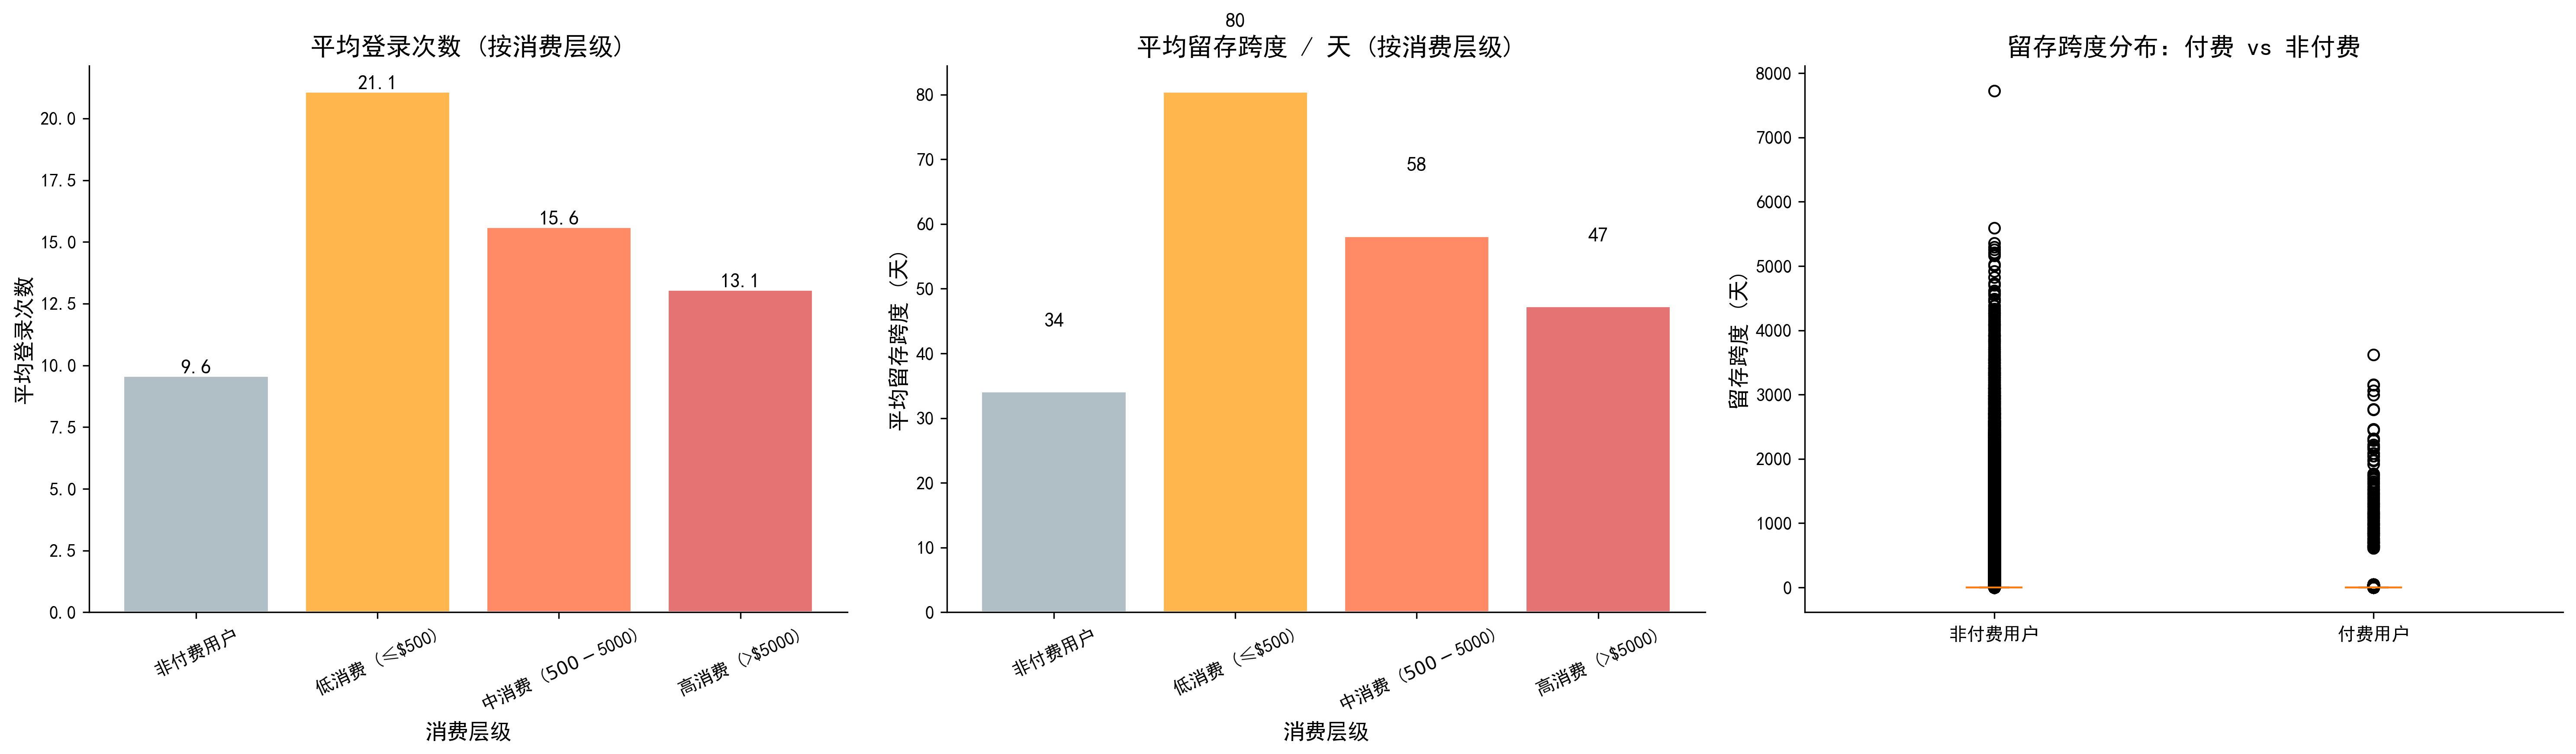

In [37]:
# ============================================================
# 第四步：可视化 — 留存 vs 消费
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 图 1：各消费层级的平均登录次数
colors = ['#b0bec5', '#ffb74d', '#ff8a65', '#e57373']
ax1 = axes[0]
bars1 = ax1.bar(tier_stats.index, tier_stats['avg_logins'], color=colors, edgecolor='white')
ax1.set_title('平均登录次数 (按消费层级)', fontsize=14, fontweight='bold')
ax1.set_ylabel('平均登录次数')
ax1.set_xlabel('消费层级')
ax1.tick_params(axis='x', rotation=25)
for bar, val in zip(bars1, tier_stats['avg_logins']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', fontsize=11)

# 图 2：各消费层级的平均留存跨度（天）
ax2 = axes[1]
bars2 = ax2.bar(tier_stats.index, tier_stats['avg_retention_span'], color=colors, edgecolor='white')
ax2.set_title('平均留存跨度 / 天 (按消费层级)', fontsize=14, fontweight='bold')
ax2.set_ylabel('平均留存跨度 (天)')
ax2.set_xlabel('消费层级')
ax2.tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, tier_stats['avg_retention_span']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:.0f}', ha='center', fontsize=11)

# 图 3：付费用户 vs 非付费用户的留存跨度分布 (箱线图)
ax3 = axes[2]
box_data = [
    user_profile[user_profile['is_payer'] == False]['retention_span'],
    user_profile[user_profile['is_payer'] == True]['retention_span']
]
bp = ax3.boxplot(box_data, labels=['非付费用户', '付费用户'], patch_artist=True)
bp['boxes'][0].set_facecolor('#b0bec5')
bp['boxes'][1].set_facecolor('#e57373')
ax3.set_title('留存跨度分布：付费 vs 非付费', fontsize=14, fontweight='bold')
ax3.set_ylabel('留存跨度 (天)')

plt.tight_layout()
plt.show()


📊 A/B 测试组内：付费 vs 非付费用户留存对比:


user_count  avg_logins  avg_span  avg_revenue
testgroup is_payer                                               
a         False         180259       17.19     64.62         0.00
          True            1723       20.53     78.17      2815.70
b         False         180961       17.35     65.25         0.00
          True            1612       15.60     58.14      3005.93

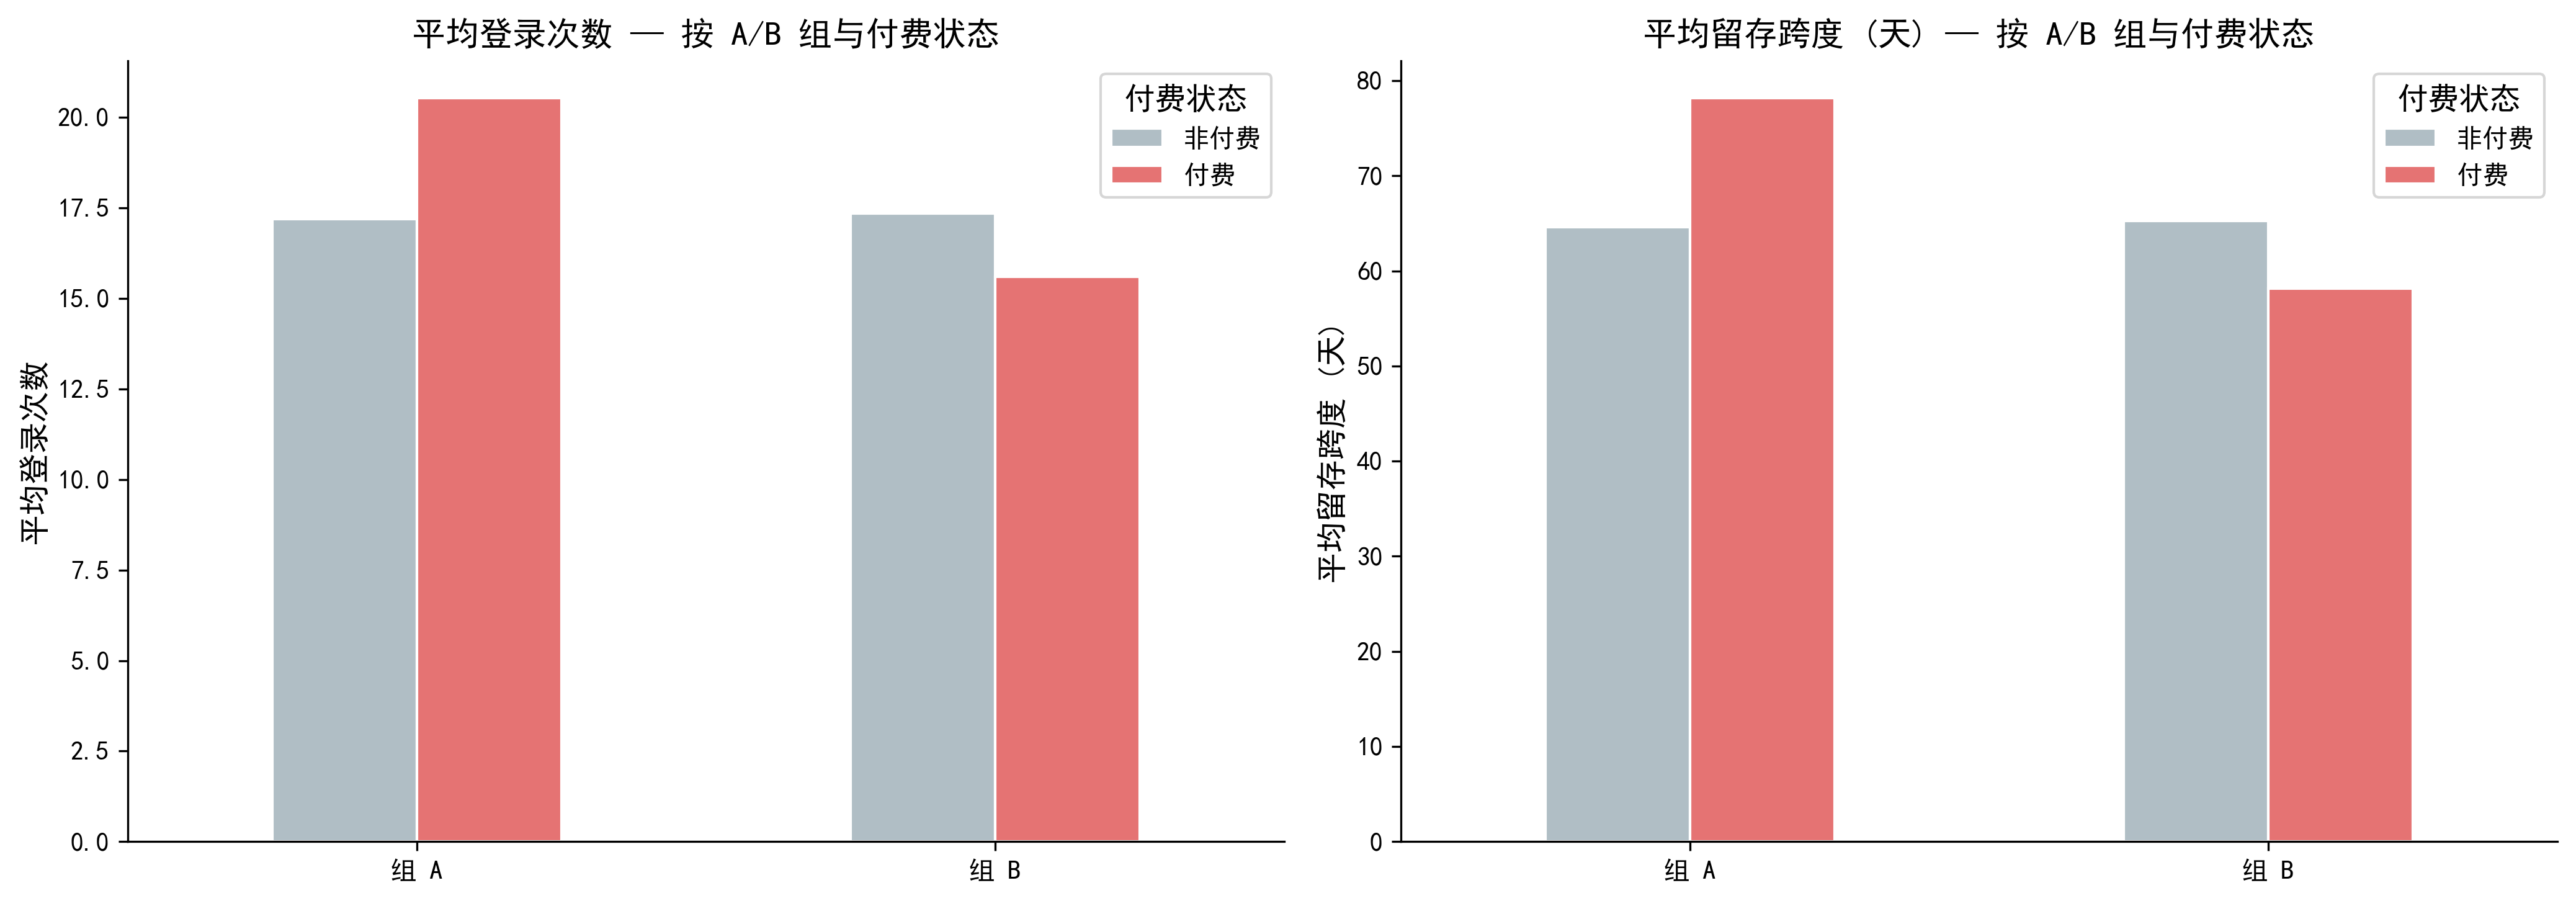

In [38]:
# ============================================================
# 第五步：按 A/B 组细分 — 各组内付费 vs 非付费用户的留存
# ============================================================

ab_retention = user_profile[user_profile['testgroup'].isin(['a', 'b'])].groupby(
    ['testgroup', 'is_payer']
).agg(
    user_count=('uid', 'count'),
    avg_logins=('total_logins', 'mean'),
    avg_span=('retention_span', 'mean'),
    avg_revenue=('total_revenue', 'mean')
).round(2)

print("\n📊 A/B 测试组内：付费 vs 非付费用户留存对比:")
display(ab_retention)

# 可视化 A/B 组差异
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, metric in enumerate(['avg_logins', 'avg_span']):
    ax = axes[i]
    pivot = ab_retention[metric].unstack(level='is_payer')
    pivot.index = [f'组 {g.upper()}' for g in pivot.index]
    pivot.columns = ['非付费', '付费']
    pivot.plot(kind='bar', ax=ax, color=['#b0bec5', '#e57373'], edgecolor='white')
    title = '平均登录次数' if metric == 'avg_logins' else '平均留存跨度 (天)'
    ax.set_title(f'{title} — 按 A/B 组与付费状态', fontsize=13, fontweight='bold')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='付费状态')

plt.tight_layout()
plt.show()


📈 付费用户群中的相关性:
   登录次数 vs 消费金额 — Pearson: -0.0201  |  Spearman: -0.0021
   留存跨度 vs 消费金额 — Pearson: -0.0207  |  Spearman: -0.0021
   (Spearman ≈ 0 说明两者无单调关系；Pearson 略负是因为少数鲸鱼拉低了均值)


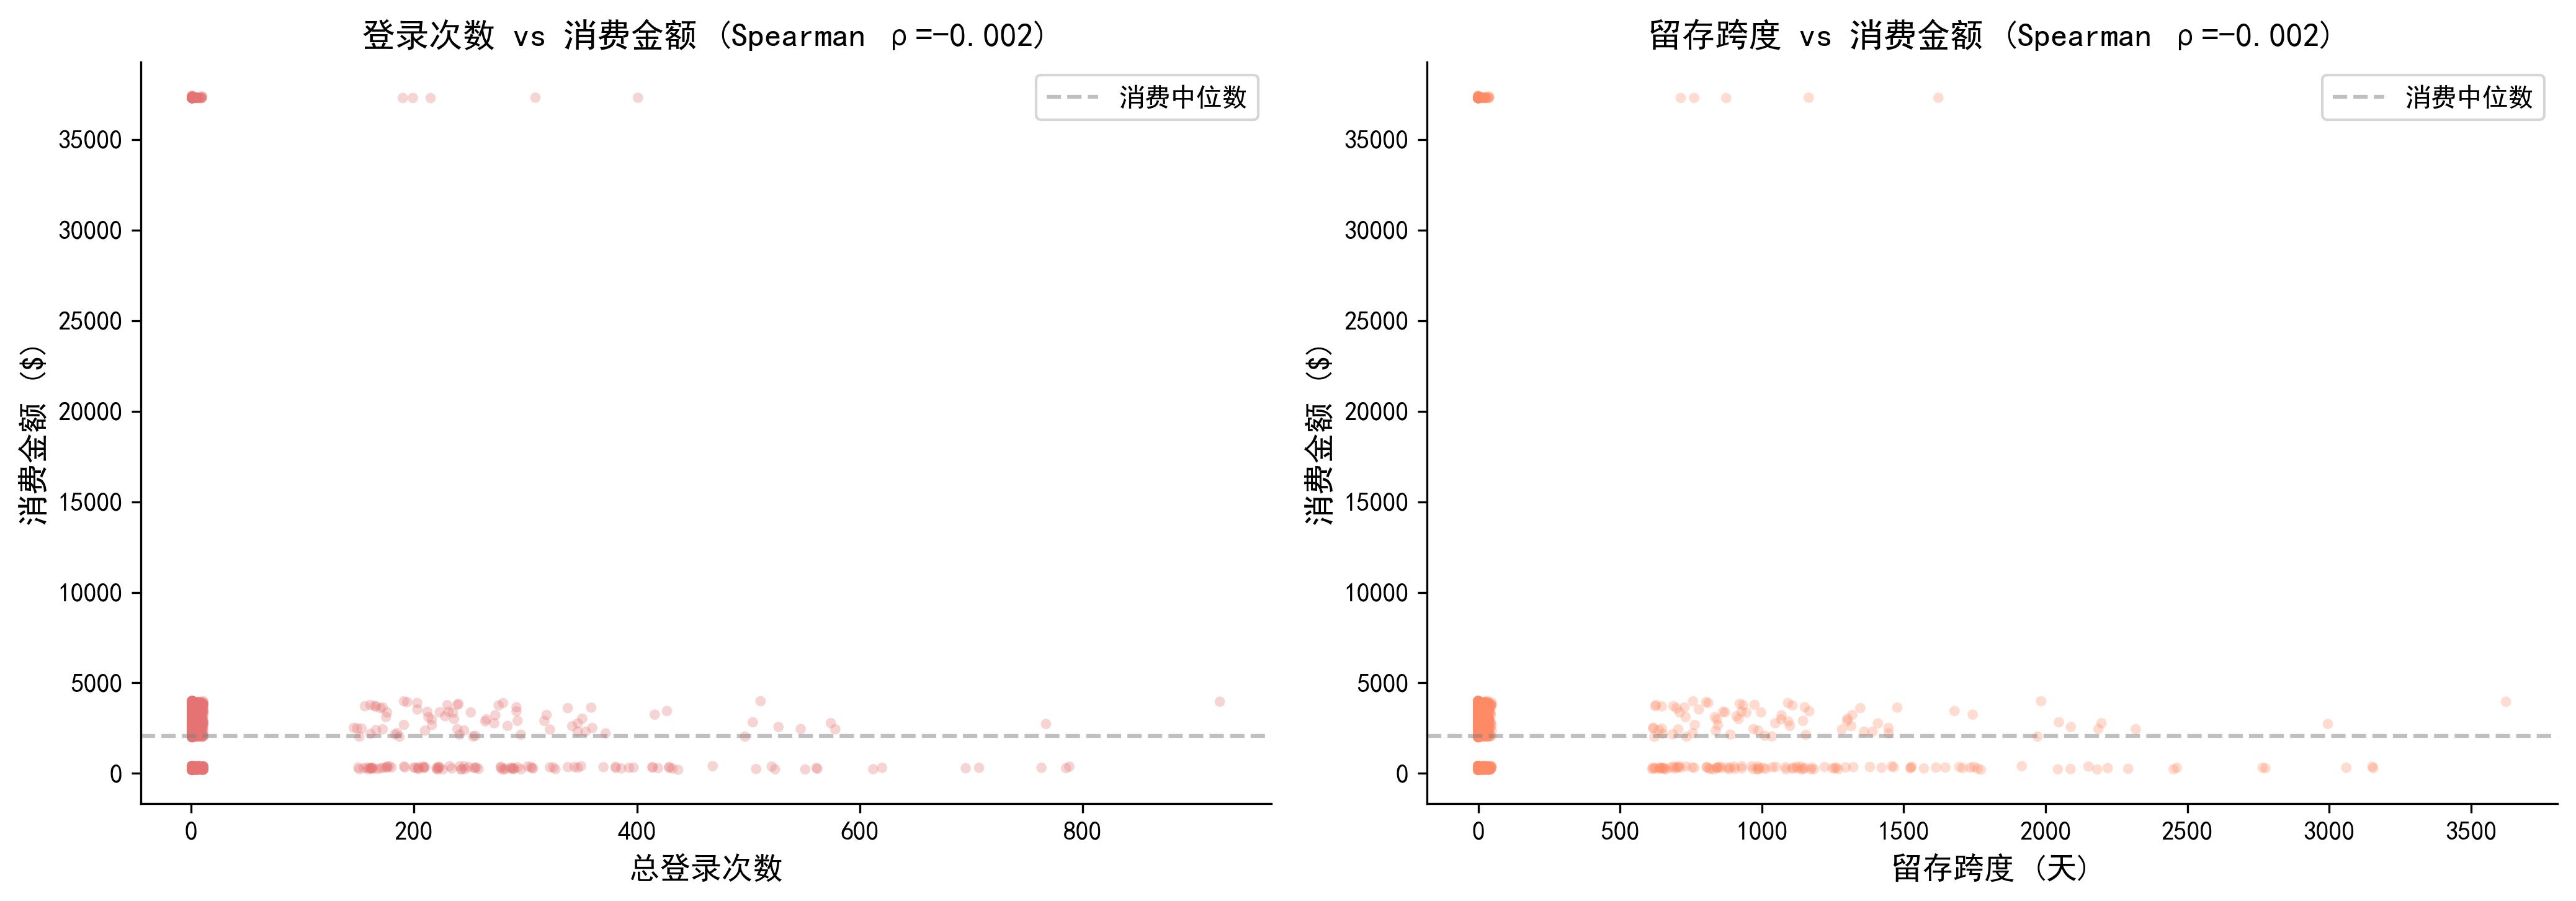


✅ 拓展问题 2 完成！
   核心发现：
   1. 消费金额与留存/活跃度之间不存在单调线性关系（Spearman ρ ≈ 0）
   2. 低消费用户（≤$500）反而是最活跃、留存最长的群体（avg 21 次登录, 80 天留存）
   3. 高消费用户（>$5000）登录次数和留存跨度均为付费用户中最低
   4. 关系呈倒 U 型：适度消费 ↔ 高参与度，而非「花得越多越活跃」
   5. 这对「普惠转化、降低氪金门槛」策略形成有力支撑——
      让更多人低门槛付费比依赖少数鲸鱼更有利于长期留存


In [39]:
# ============================================================
# 第六步：相关性量化
# ============================================================

# 计算登录次数与消费金额的相关系数（仅限付费用户）
payers = user_profile[user_profile['is_payer']]

# Pearson（对离群值敏感）
pearson_logins = payers['total_logins'].corr(payers['total_revenue'])
pearson_span   = payers['retention_span'].corr(payers['total_revenue'])

# Spearman 秩相关（对离群值鲁棒，检验单调关系）
spearman_logins = payers['total_logins'].corr(payers['total_revenue'], method='spearman')
spearman_span   = payers['retention_span'].corr(payers['total_revenue'], method='spearman')

print("\n📈 付费用户群中的相关性:")
print(f"   登录次数 vs 消费金额 — Pearson: {pearson_logins:+.4f}  |  Spearman: {spearman_logins:+.4f}")
print(f"   留存跨度 vs 消费金额 — Pearson: {pearson_span:+.4f}  |  Spearman: {spearman_span:+.4f}")
print(f"   (Spearman ≈ 0 说明两者无单调关系；Pearson 略负是因为少数鲸鱼拉低了均值)")

# 散点图 + 回归线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(payers['total_logins'], payers['total_revenue'],
            alpha=0.3, c='#e57373', edgecolors='none')
ax1.set_title(f'登录次数 vs 消费金额 (Spearman ρ={spearman_logins:+.3f})', fontsize=13, fontweight='bold')
ax1.set_xlabel('总登录次数')
ax1.set_ylabel('消费金额 ($)')
# 标注中位线
ax1.axhline(y=payers['total_revenue'].median(), color='gray', linestyle='--', alpha=0.5, label='消费中位数')
ax1.legend()

ax2 = axes[1]
ax2.scatter(payers['retention_span'], payers['total_revenue'],
            alpha=0.3, c='#ff8a65', edgecolors='none')
ax2.set_title(f'留存跨度 vs 消费金额 (Spearman ρ={spearman_span:+.3f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('留存跨度 (天)')
ax2.set_ylabel('消费金额 ($)')
ax2.axhline(y=payers['total_revenue'].median(), color='gray', linestyle='--', alpha=0.5, label='消费中位数')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n✅ 拓展问题 2 完成！")
print("   核心发现：")
print("   1. 消费金额与留存/活跃度之间不存在单调线性关系（Spearman ρ ≈ 0）")
print("   2. 低消费用户（≤$500）反而是最活跃、留存最长的群体（avg 21 次登录, 80 天留存）")
print("   3. 高消费用户（>$5000）登录次数和留存跨度均为付费用户中最低")
print("   4. 关系呈倒 U 型：适度消费 ↔ 高参与度，而非「花得越多越活跃」")
print("   5. 这对「普惠转化、降低氪金门槛」策略形成有力支撑——")
print("      让更多人低门槛付费比依赖少数鲸鱼更有利于长期留存")